#### ⏰ Deadline: Wednesday, July 1, 20:00
### What is this notebook about?

Many machine learning models produce probabilities, but can those probabilities be trusted?
Meet the concept of calibration! A model is well-calibrated if its predicted probabilities match observed outcomes. For example, among all patients assigned an 80% risk, we would expect about 80% to actually have the disease.
In this notebook you will get intuitions on what calibration is and how to achieve it. 

🚀 Time to get started! 

---
### **Important** 

Please note that the notebook contains images that will show when viewing them online in the Jupyter Book but may not show once you download the notebook. So, please consult the web version to view the images for stations that rely on them: https://mbp-lab.github.io/sose26-real-world-problems-ai/validation/

---
#### 🟢 Station 1 - Why calibration matters

Let's start by considering a hypothetical scenario.

A hospital in a remote rural area has started using a machine learning model to estimate a patient's risk of having an undiagnosed disease. While the hospital benefits from modern AI tools, it still faces limited resources. The state only funds a limited number of diagnostic tests each month, so not every patient can be referred for additional screening.

As a result, only patients above a certain predicted risk threshold are referred. The historical dataset of the hospital is available to you.

- Load the dataset `rural_screening.csv` (fill in this step in the code below)
- It contains patient features, the true `disease` label and model `predicted_risk` scores from an undisclosed model
- We will apply a threshold of 0.5 and calculate model accuracy (already implemented below)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("../data/rural_screening.csv")

THRESHOLD = 0.5
y_true = df["disease"]
y_pred = (df["predicted_risk"] >= THRESHOLD).astype(int)

accuracy = accuracy_score(y_true, y_pred)
n_referred = y_pred.sum()

print(f"Patients: {len(df)}")
print(f"Disease prevalence: {y_true.mean():.1%}")
print(f"Threshold: {THRESHOLD}")
print(f"Patients referred: {n_referred} / {len(df)} ({100 * n_referred / len(df):.1f}%)")
print(f"Model accuracy: {accuracy:.3f}")

Patients: 3000
Disease prevalence: 27.5%
Threshold: 0.5
Patients referred: 556 / 3000 (18.5%)
Model accuracy: 0.793


---
#### 🟢 Station 1 - Why calibration matters - continued

It seems that out of 3,000 patients, only a small fraction are referred for additional screening. Given the hospital's limited resources, this initially appears to be a sensible strategy.

However, the screening program has become increasingly concerned that the model may not be performing as well in practice. To investigate these concerns, the hospital hires a machine learning team to evaluate whether the model's predicted risks can actually be trusted.

The team leader requests visualizations (sketches below) to get a better picture of what's going on. 

- **Your job** is to implement the visualizations based on the code snippet below (fill in your part at the end of the code cell)
- But don't rush to the code yet! Look at the plots and write down what information you would need to create them.
- Find that information in the code snippet below. Some of the information is missing and you should fill it in!

![Caption](../images/sketch.jpg)




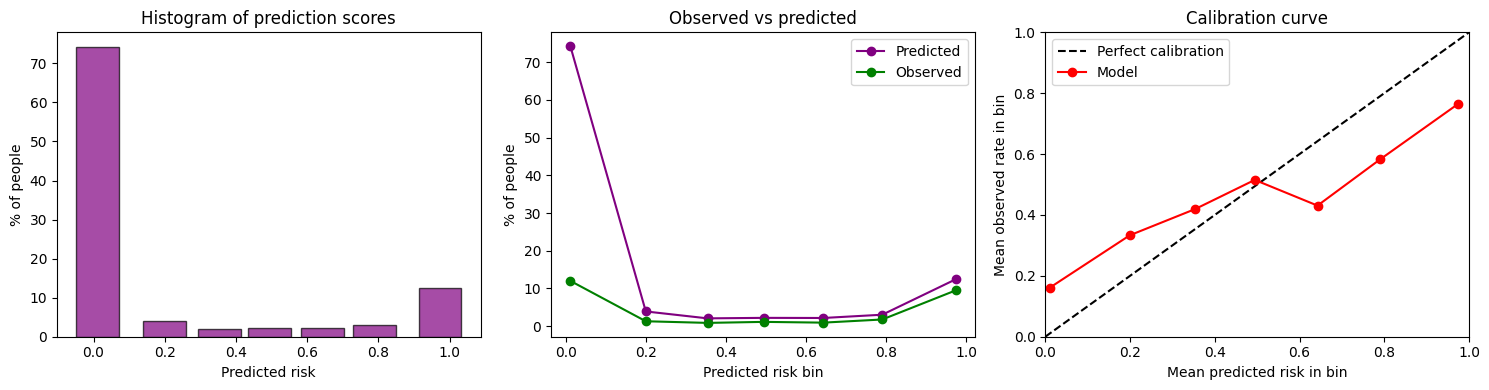

,risk_bin,mean_predicted_risk,observed_disease_rate,n_patients
0,"(-0.001, 0.143]",0.011171,0.161652,2227
1,"(0.143, 0.286]",0.199554,0.333333,117
2,"(0.286, 0.429]",0.353619,0.419355,62
3,"(0.429, 0.571]",0.494396,0.515152,66
4,"(0.571, 0.714]",0.642464,0.430769,65
5,"(0.714, 0.857]",0.789954,0.582418,91
6,"(0.857, 1.0]",0.972945,0.763441,372


In [2]:
# Some code to get started
# It has some of the information needed for the plots but not all!
# But you should be able to implement the missing parts easily based on waht

from IPython.display import display

N_BINS = 7

# Divide the predicted risks into equally sized bins
df["risk_bin"] = pd.cut(
    df["predicted_risk"],
    bins=np.linspace(0, 1, N_BINS + 1),
    include_lowest=True)

grouped = df.groupby("risk_bin", observed=True)

# For each bin, compute the mean predicted risk, the observed disease rate and number of patients in each bin
calibration_table = pd.DataFrame({
    "mean_predicted_risk": grouped["predicted_risk"].mean(),
    "observed_disease_rate": grouped["disease"].mean(),
    "n_patients": grouped["disease"].size()}).reset_index()


# Extract the columns as NumPy arrays for plotting
bin_centers = calibration_table["mean_predicted_risk"].to_numpy()
mean_predicted = calibration_table["mean_predicted_risk"].to_numpy()
mean_observed = calibration_table["observed_disease_rate"].to_numpy()
n_patients = calibration_table["n_patients"].to_numpy()

pct_in_bin = 100 * n_patients / len(df)
pct_diseased_in_bin = 100 * n_patients * calibration_table["observed_disease_rate"] / len(df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sketch 1: histogram of prediction scores
axes[0].bar(bin_centers, pct_in_bin, width=0.12, color="purple", alpha=0.7, edgecolor="black")
axes[0].set_title("Histogram of prediction scores")
axes[0].set_xlabel("Predicted risk")
axes[0].set_ylabel("% of people")

# Sketch 2: observed vs predicted
axes[1].plot(bin_centers, pct_in_bin, "o-", color="purple", label="Predicted")
axes[1].plot(bin_centers, pct_diseased_in_bin, "o-", color="green", label="Observed")
axes[1].set_title("Observed vs predicted")
axes[1].set_xlabel("Predicted risk bin")
axes[1].set_ylabel("% of people")
axes[1].legend()

# Sketch 3: calibration curve
axes[2].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[2].plot(mean_predicted, mean_observed, "ro-", label="Model")
axes[2].set_title("Calibration curve")
axes[2].set_xlabel("Mean predicted risk in bin")
axes[2].set_ylabel("Mean observed rate in bin")
axes[2].legend()
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

display(calibration_table)

### 💡 Station 1 - Reflection

**Reminder**: A model is well-calibrated if its predicted probabilities match observed outcomes. For example, among all patients assigned an 80% risk, we would expect about 80% to actually have the disease.

- Why were these plots suggested? Which parts of the plots give information about the calibration quality?
- What do you observe? Is the model well-calibrated: does the predicted risk match the actual risk?
- What are the real-life consequences for a model like this? 👀Hint: think of the decision threshold!

---
#### 🟢🟢 Station 2 - Improving calibration

**ML team's decision on how to move on**

Based on the previous results, the ML team decides to recalibrate the model. Since they only have access to the model's predicted risk scores, not the underlying model itself, they use post-hoc calibration methods.

Post-hoc calibration means learning a correction to bring the original predicted risk closer to the actual risk! We cannot retrain the original model as it's not disclosed in our scenario. However, we can do something about those prediction scores. 

--- 
**Considered methods**

The post-hoc models they consider are:

**Temperature Scaling**: intuitively, it turns the model's confidence up or down by a fixed amount for all predictions. This is done by adjusting the predicted risks by first expressing them on the log-odds (logit) scale, where the logit is defined as $\text{logit}(p) = \log\left(\frac{p}{1-p}\right)$. These log-odds are then divided by a single parameter called the temperature $T$ and transformed back into probabilities. A temperature above 1 makes predictions less extreme, while a temperature below 1 makes them more extreme. The temperature is learned from the calibration set by finding the value that best matches predicted risks to observed disease rates.

**Isotonic Regression**: intuitively, it applies a second machine learning model to transform the original risk scores into better-calibrated probabilities. It fits a regression model that learns how predicted risks relate to observed disease rates. This relationship is constrained to be isotonic, meaning that regression preserves the ordering of the predictions. In Python, this can be implemented with `sklearn.isotonic.IsotonicRegression`.


- Check the code below and fill in the missing information to perform re-calibration.
- That will guide you to 1) run re-calibration 2) estimate how predicted probabilities match the observed ones (`brier_score_loss`) 3) visualize the results of the recalibration

Learned temperature: 4.272


,Method,Brier score,Accuracy,Patients referred
0,Original,0.1871,0.785,100
1,Temperature scaling,0.1479,0.785,100
2,Isotonic regression,0.1476,0.790,91


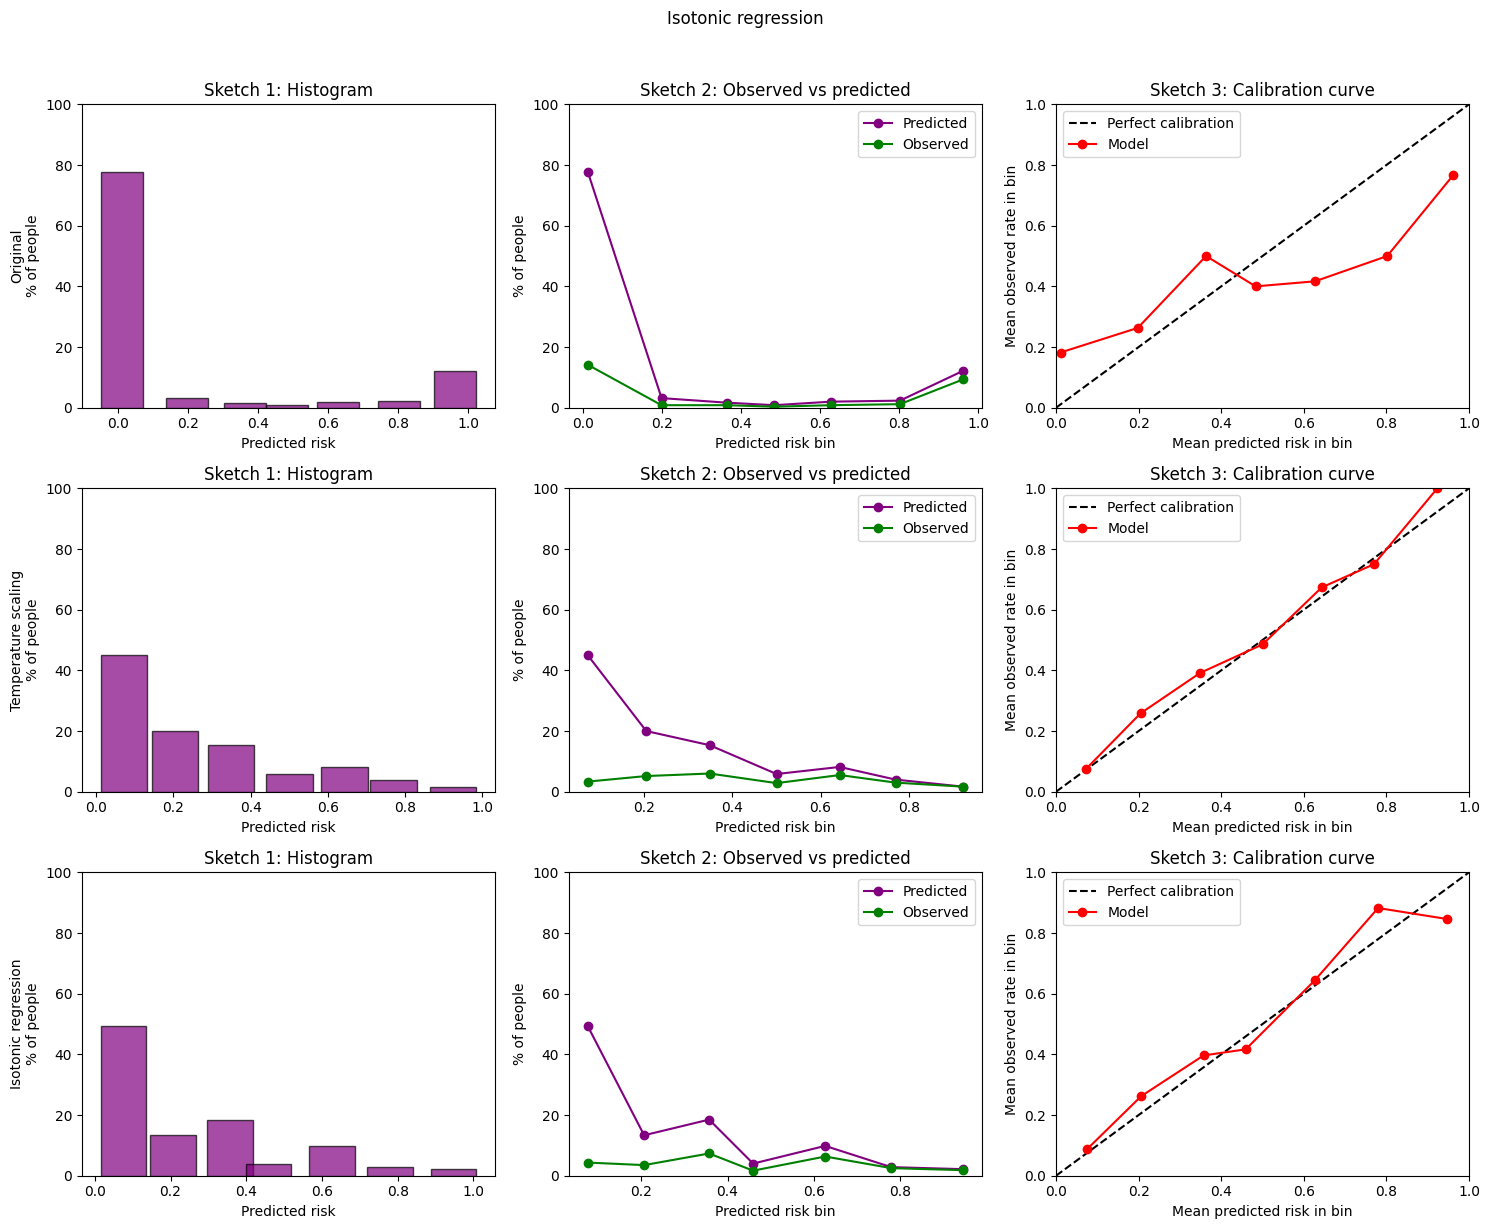

In [5]:
from scipy.optimize import minimize_scalar
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split

N_BINS = 7
THRESHOLD = 0.5

# Split the data into a calibration set (80%) and a test set (20%)
cal_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=df["disease"],
)

raw_cal = df.loc[cal_idx, "predicted_risk"].to_numpy()
y_cal = df.loc[cal_idx, "disease"].to_numpy()

raw_test = df.loc[test_idx, "predicted_risk"].to_numpy()
y_test = df.loc[test_idx, "disease"].to_numpy()


def logits_from_probabilities(probabilities, eps=1e-6):
    probabilities = np.clip(probabilities, eps, 1 - eps)
    return np.log(probabilities / (1 - probabilities))


def probabilities_from_logits(logits):
    return 1 / (1 + np.exp(-logits))


def apply_temperature(probabilities, temperature):
    logits = logits_from_probabilities(probabilities)
    return probabilities_from_logits(logits / temperature)


def fit_temperature(probabilities, y):
    def loss(temperature):
        calibrated = apply_temperature(probabilities, temperature)
        calibrated = np.clip(calibrated, 1e-6, 1 - 1e-6)
        return -np.mean(
            y * np.log(calibrated) + (1 - y) * np.log(1 - calibrated))

    result = minimize_scalar(loss, bounds=(0.05, 20), method="bounded")
    return result.x


temperature = fit_temperature(raw_cal, y_cal)
temp_test = apply_temperature(raw_test, temperature)

print(f"Learned temperature: {temperature:.3f}")


# -----------------------------
# TODO 1
# Fit isotonic regression on the calibration set.
# -----------------------------
iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(raw_cal, y_cal)
iso_test = iso_reg.predict(raw_test)


def calibration_table_from_scores(y_true, y_proba, n_bins=N_BINS):
    """Build the same summary table used in Station 1 for any set of risk scores."""
    bins = pd.cut(y_proba, bins=np.linspace(0, 1, n_bins + 1), include_lowest=True)
    grouped = pd.DataFrame({"y": y_true, "p": y_proba, "bin": bins}).groupby("bin", observed=True)
    return pd.DataFrame({
        "mean_predicted_risk": grouped["p"].mean(),
        "observed_disease_rate": grouped["y"].mean(),
        "n_patients": grouped["y"].size(),
    }).reset_index()


def plot_calibration_sketches(axes, table, total_n, suptitle=None):
    """Plot Station 1 sketches 1-3 on a row of three axes."""
    bin_centers = table["mean_predicted_risk"].to_numpy()
    mean_predicted = table["mean_predicted_risk"].to_numpy()
    mean_observed = table["observed_disease_rate"].to_numpy()
    n_patients = table["n_patients"].to_numpy()

    pct_in_bin = 100 * n_patients / total_n
    pct_diseased_in_bin = 100 * n_patients * table["observed_disease_rate"] / total_n

    axes[0].bar(bin_centers, pct_in_bin, width=0.12, color="purple", alpha=0.7, edgecolor="black")
    axes[0].set_title("Sketch 1: Histogram")
    axes[0].set_xlabel("Predicted risk")
    axes[0].set_ylabel("% of people")

    axes[1].plot(bin_centers, pct_in_bin, "o-", color="purple", label="Predicted")
    axes[1].plot(bin_centers, pct_diseased_in_bin, "o-", color="green", label="Observed")
    axes[1].set_title("Sketch 2: Observed vs predicted")
    axes[1].set_xlabel("Predicted risk bin")
    axes[1].set_ylabel("% of people")
    axes[1].legend()

    axes[2].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    axes[2].plot(mean_predicted, mean_observed, "ro-", label="Model")
    axes[2].set_title("Sketch 3: Calibration curve")
    axes[2].set_xlabel("Mean predicted risk in bin")
    axes[2].set_ylabel("Mean observed rate in bin")
    axes[2].legend()
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1)

    if suptitle:
        axes[0].figure.suptitle(suptitle, y=1.02)


# -----------------------------
# TODO 2
# Compare the methods using Brier score and accuracy
# -----------------------------
methods = [
    ("Original", raw_test),
    ("Temperature scaling", temp_test),
    ("Isotonic regression", iso_test),
]

metrics = pd.DataFrame({
    "Method": [name for name, _ in methods],
    "Brier score": [brier_score_loss(y_test, probs) for _, probs in methods],
    "Accuracy": [
        accuracy_score(y_test, (probs >= THRESHOLD).astype(int))
        for _, probs in methods
    ],
    "Patients referred": [
        int((probs >= THRESHOLD).sum()) for _, probs in methods
    ],
})

display(metrics.style.format({
    "Brier score": "{:.4f}",
    "Accuracy": "{:.3f}",
}))


# -----------------------------
# TODO 3
# Recreate all Station 1 sketches for each method on the test set
# -----------------------------
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for row, (name, probs) in enumerate(methods):
    table = calibration_table_from_scores(y_test, probs)
    plot_calibration_sketches(
        axes[row],
        table,
        total_n=len(y_test),
        suptitle=name,
    )
    axes[row, 0].set_ylabel(f"{name}\n% of people")
    axes[row, 0].set_ylim(0,100)
    axes[row, 1].set_ylim(0,100)


plt.tight_layout()
plt.show()


### 💡 Station 2 - Reflection

- What happens after recalibration?
- What does the Brier score reflect?
   - 👀Check out how it's calculated
   - Describe it intuitively by using sketch 2 from Station 1! 

---

#### 🟢🟢🟢 Station 3 - Visualizing "confidence" 

The ML team now wants to communicate the model's predictions to the clinical team in a intuitive way. Rather than presenting technical metrics or tables, they decide to create simple visualizations. A useful way of doing this is visualizing the dataset as scatterplot (Feature 1 vs Feature 2). Next, one could create versions of this scatterplot by coloring each data point according to its predicted risk.

- Create the described visualizations for the original and recalibrated models.
- Write down *one* (and only one!) paragraph that would explain what the figures show to a non-technical audience! 

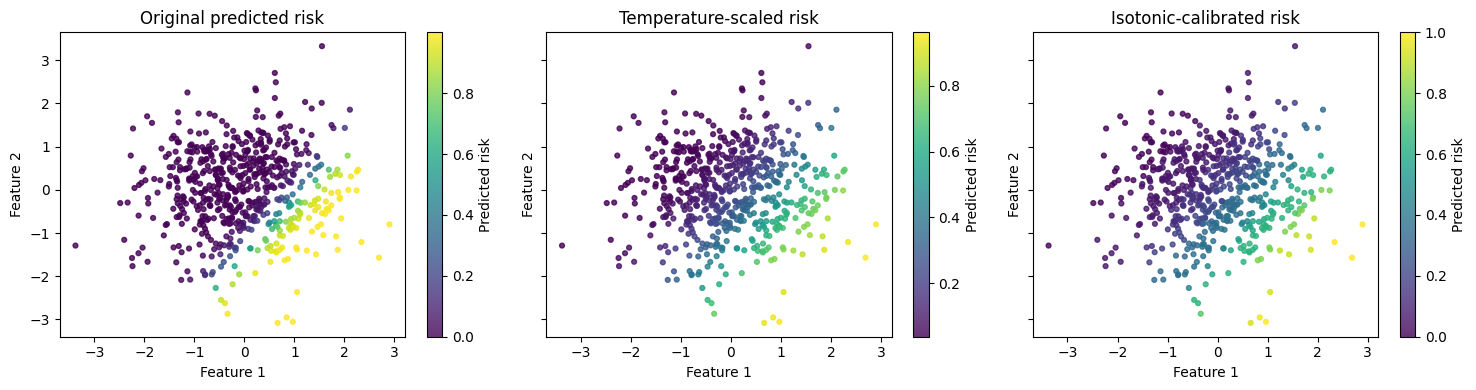

In [4]:
test_df = df.loc[test_idx].copy()
test_df["temp_risk"] = temp_test
test_df["iso_risk"] = iso_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

risk_columns = [
    ("predicted_risk", "Original predicted risk"),
    ("temp_risk", "Temperature-scaled risk"),
    ("iso_risk", "Isotonic-calibrated risk"),
]

for ax, (column, title) in zip(axes, risk_columns):
    scatter = ax.scatter(
        test_df["feature 1"],
        test_df["feature 2"],
        c=test_df[column],
        cmap="viridis",
        s=12,
        alpha=0.8,
    )
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    fig.colorbar(scatter, ax=ax, label="Predicted risk")

plt.tight_layout()
plt.show()

### 💡 Station 3 - Reflection

Write down *one* (and only one!) paragraph that would explain what the figures show to a non-technical audience! 


---
####  Can the tutor add your visualizations to the class notes? A gallery of student results helps see how different people approach the problem.

[Optional] 🤔💭 Was there something you struggled with? Are there any open questions?